In [14]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt

### Załadowanie danych

In [15]:
image_dataset_from_directory = tf.keras.utils.image_dataset_from_directory

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    "dataset/train",            
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    "dataset/valid",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    "dataset/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 1767 files belonging to 6 classes.
Found 504 files belonging to 6 classes.
Found 253 files belonging to 6 classes.


### Sprawdzenie klas

In [16]:
class_names = test_ds.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### Sprawdzenie poprawności kształtu etykiet i rozmiaru batchu

In [17]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


### Wyświetlenie obrazu do sprawdzenia poprawności ich odczytu

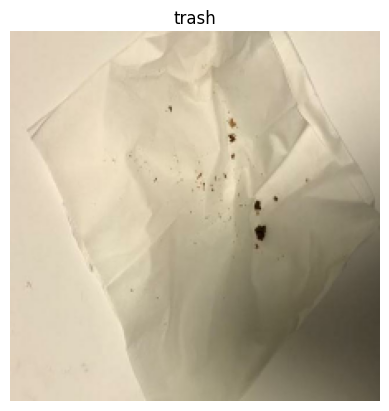

In [18]:
for images, labels in train_ds.take(1):
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(class_names[labels[0]])
    plt.axis("off")
    plt.show()

### Optymalizacja wczytywania danych (by trening szedł szybciej)

In [19]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

### Augmentacja datasetu (urozmaicenie)

In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

### Przygotowanie gotowego modelu z transfer learningiem (EfficientNetB0)

In [21]:
base_model = tf.keras.applications.EfficientNetB0(
  input_shape=IMAGE_SIZE + (3,),
  include_top=False,
  weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Trening naszego modelu

In [23]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)]
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 45s 713ms/step - accuracy: 0.6610 - loss: 0.9079 - val_accuracy: 0.8413 - val_loss: 0.4835
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 39s 699ms/step - accuracy: 0.8240 - loss: 0.5022 - val_accuracy: 0.8631 - val_loss: 0.4057
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 45s 809ms/step - accuracy: 0.8466 - loss: 0.4280 - val_accuracy: 0.8671 - val_loss: 0.4008
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 34s 607ms/step - accuracy: 0.8761 - loss: 0.3642 - val_accuracy: 0.8770 - val_loss: 0.3678
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 49s 871ms/step - accuracy: 0.8851 - loss: 0.3327 - val_accuracy: 0.8690 - val_loss: 0.3547
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 56s 999ms/step - accuracy: 0.8953 - loss: 0.2982 - val_accuracy: 0.8829 - val_loss: 0.3525
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 53s 958ms/step - accuracy: 0.9038 - loss: 0.2660 - val_accuracy: 0.8730 - val_loss: 0.3705
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 53s 954ms/step - accuracy: 0.9151 - loss: 0.2483 - val_accu

### Fine-tuning naszego modelu (uaktywnianie modelu bazowego)

In [24]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
    
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)]
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8766 - loss: 0.3807 - val_accuracy: 0.8929 - val_loss: 0.3386
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 958ms/step - accuracy: 0.9089 - loss: 0.2624 - val_accuracy: 0.8889 - val_loss: 0.3320
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9219 - loss: 0.2379 - val_accuracy: 0.8889 - val_loss: 0.3329
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9389 - loss: 0.1932 - val_accuracy: 0.8948 - val_loss: 0.3224
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9474 - loss: 0.1707 - val_accuracy: 0.8988 - val_loss: 0.3206
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9553 - loss: 0.1523 - val_accuracy: 0.9048 - val_loss: 0.3063
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9598 - loss: 0.1342 - val_accuracy: 0.8988 - val_loss: 0.3060
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9604 - loss: 0.1257 - val_accuracy: 0.8929 - val_lo

### Sprawdzanie wyników na test datasecie

In [25]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 434ms/step - accuracy: 0.9012 - loss: 0.3146
Test accuracy: 0.9012
Test loss: 0.3146


### Wykresy wyników i macierz pomyłek

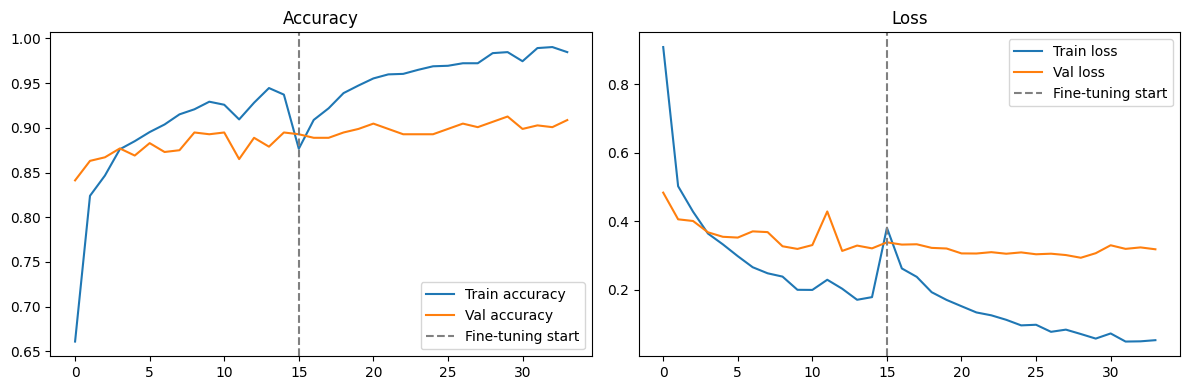

              precision    recall  f1-score   support

   cardboard       1.00      0.93      0.96        44
       glass       0.92      0.94      0.93        47
       metal       0.90      0.95      0.93        40
       paper       0.89      0.92      0.91        64
     plastic       0.88      0.82      0.85        44
       trash       0.67      0.71      0.69        14

    accuracy                           0.90       253
   macro avg       0.88      0.88      0.88       253
weighted avg       0.90      0.90      0.90       253



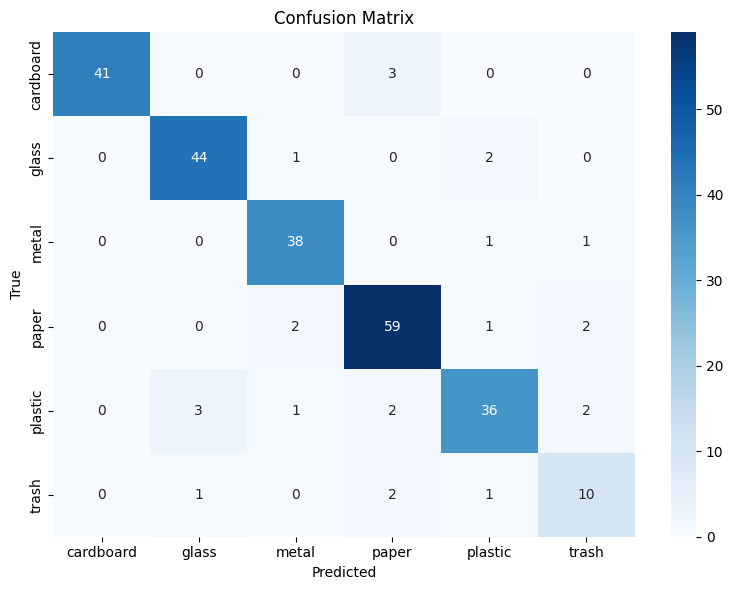

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Wykresy treningu
def plot_history(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(acc, label="Train accuracy")
    plt.plot(val_acc, label="Val accuracy")
    plt.axvline(x=len(h1.history["accuracy"]), color="gray", linestyle="--", label="Fine-tuning start")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(loss, label="Train loss")
    plt.plot(val_loss, label="Val loss")
    plt.axvline(x=len(h1.history["loss"]), color="gray", linestyle="--", label="Fine-tuning start")
    plt.legend()
    plt.title("Loss")
    
    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

# Macierz pomyłek
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Raport klasyfikacji
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Krótkie podsumowanie

W tym projekcie staramy się posortować śmieci (sklasyfikować je) na 6 klas na podstawie wyglądu/zdjęć. W celu przyśpieszenia uczenia stosujemy optymalizację wczytywania danych po pierwszej epoce,
dzięki czemu kolejne uczą się tak średnio o połowę krócej. Stosujemy też sztucznę urozmaicenie zdjęć (tzw. augmentację) modyfikując dostępne obrazy w czasie treningu z każdą epoką, by model wyszkolił się na bardziej zróżnicowanych obrazach, a nie takich samych. Jako pierwszy model wykorzystałem gotowy model AI zwany EfficientNetB0, który był już wyszkolony na wielu milionach obrazów, dzięki czemu wszystkie nasze obrazy ulegają też normalizacji (nie musimy tego robić sami, bo gotowy model domyślnie normalizuje obrazy), jednak nie używamy go w 1 fazie do uczenia się naszych zdjęć z datasetu. W pierwszej kolejności implementujemy naszą sieć neuronową z różnymi parametrami, które pomagają jej w uczeniu np. parametr Dropout(0,2) i wyszkalamy go na obrazach z podkatalogu train oraz zapewniamy walidację w postaci zdjęć z katalogu val. Po wyszkoleniu naszego modelu przystępujemy do fazy 2 - Fine-tuningu tzw. ulepszania modelu, w tym celu odmrażamy ileś (30) ostatnich warstw modelu gotowego, by wspomógł utworzony przez nas model i poprawił jego wyniki. Na końcu testujemy nasz model na zdjeciach z podfolderu test, zwracamy wynik, a także zwracamy wykresy przebiegu naszego uczonego modelu, jego raport klasyfikacji oraz macierz pomyłek. Wynik 1 fazy to średnio: accuracy: 0.9372 - loss: 0.1788 - val_accuracy: 0.8948 - val_loss: 0.3210, natomiast wyniki fazy 2 wynoszą: accuracy: 0.9847 - loss: 0.0533 - val_accuracy: 0.9087 - val_loss: 0.3183. Wyniki na datasecie testowym wynoszą średnio ok.: Test accuracy: 0.9012
Test loss: 0.3146. Z raportu klasyfikacji wiemy, że z większością kategorii nasz model nie ma problemu (wyniki accuracy średnio 0.88-0.92) przy czym z kartonami osiąga nawet wartość 1.00, natomiast z kategorią śmieci ma istotny problem, gdyż wynik to zaledwie 0,67. Może to wynikać z tego, iż śmieci są podobne do innych kategorii, przez co trafiają gdzie indziej lub też dlatego, iż możemy mieć za małą bazę obrazów z kategorią "trash".